# AI vs Human Text Detection System
**Problem Statement — Hackathon Submission**

---

## About the Dataset

- **Source:** [LLM Detect AI Generated Text Dataset — Hugging Face](https://huggingface.co/datasets/artem9k/ai-text-detection-pile)
- **Format:** Parquet files (train split: 3 files, test split: 1 file)
- **Total training samples:** ~462,000 (we sample 30,000 for faster training)
- **Columns:**
  - `text` — the essay/passage content
  - `generated` — label: `0` = Human-written, `1` = AI-generated
- **Class distribution (sampled):** roughly 63% Human, 37% AI

## Preprocessing Steps
1. Lowercase all text
2. Remove punctuation and special characters
3. Strip extra whitespace
4. Vectorize using **TF-IDF** (Term Frequency–Inverse Document Frequency)

## Models Trained
1. **Logistic Regression** — good baseline for text classification
2. **Multinomial Naive Bayes** — classic, fast, works well with bag-of-words

## Decision Layer Thresholds
| Confidence (P(Human)) | Decision |
|---|---|
| ≥ 0.80 | ✅ Acceptable — Likely Human |
| 0.60 – 0.79 | ❓ Needs Review — Uncertain |
| < 0.60 | ⚠ Likely AI-generated |


---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load Dataset

In [2]:
# Load all 3 train parquet files and combine
train_parts = []
for i in range(3):
    path = f"dataset/train-0000{i}-of-00003.parquet"
    df_part = pd.read_parquet(path)
    train_parts.append(df_part)

df_full = pd.concat(train_parts, ignore_index=True)
print(f"Full training dataset shape: {df_full.shape}")
print(f"\nLabel distribution (full):")
print(df_full['generated'].value_counts().rename({0: 'Human (0)', 1: 'AI (1)'})
      .to_frame('count'))

Full training dataset shape: (462873, 2)

Label distribution (full):
            count
generated        
Human (0)  290672
AI (1)     172201


In [3]:
# Sample 30,000 rows (balanced) for faster training — student machine friendly
SAMPLE_PER_CLASS = 15000

df_human = df_full[df_full['generated'] == 0].sample(SAMPLE_PER_CLASS, random_state=42)
df_ai    = df_full[df_full['generated'] == 1].sample(SAMPLE_PER_CLASS, random_state=42)

df = pd.concat([df_human, df_ai], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")
print(f"\nLabel distribution (sampled):")
print(df['generated'].value_counts().rename({0: 'Human (0)', 1: 'AI (1)'}).to_frame('count'))
df.head()

Sampled dataset shape: (30000, 2)

Label distribution (sampled):
           count
generated       
Human (0)  15000
AI (1)     15000


,text,generated
0,man kind has always envisioned a radical futur...,0
1,in recent years technology has become an inte...,1
2,i think that schools should not allow parents ...,1
3,the benefits of spending time outdoorsspending...,1
4,sometimes people ask for advice to hear other ...,0


---
## Step 3: Exploratory Data Analysis

=== Text Length Stats ===
           text_length  word_count
generated                         
Human      2281.260267  414.510800
AI         2067.686200  339.250867


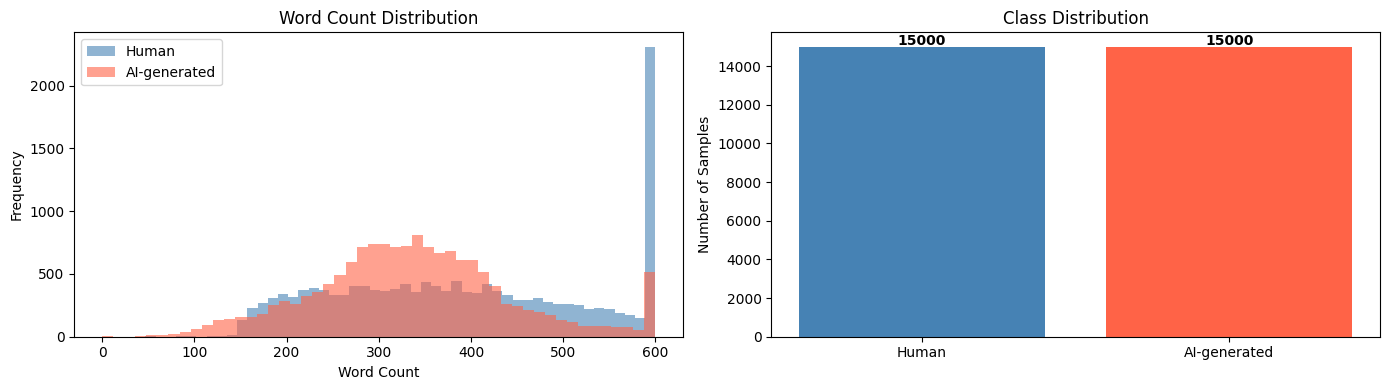

In [4]:
# Text length distribution
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

print("=== Text Length Stats ===")
print(df.groupby('generated')[['text_length', 'word_count']].mean().rename(index={0:'Human', 1:'AI'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, name, color in [(0, 'Human', 'steelblue'), (1, 'AI-generated', 'tomato')]:
    subset = df[df['generated'] == label]['word_count']
    axes[0].hist(subset.clip(upper=600), bins=50, alpha=0.6, label=name, color=color)

axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

counts = df['generated'].value_counts()
axes[1].bar(['Human', 'AI-generated'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 4: Text Preprocessing

In [5]:
def preprocess_text(text):
    """
    Preprocessing pipeline:
    1. Convert to lowercase
    2. Remove punctuation and special characters
    3. Remove extra whitespace
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation and non-alphabetic chars (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 3: Strip extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
print("Preprocessing texts...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Done!")

# Show before/after example
print("\n--- Before preprocessing ---")
print(df['text'].iloc[0][:200])
print("\n--- After preprocessing ---")
print(df['clean_text'].iloc[0][:200])

Preprocessing texts...
Done!

--- Before preprocessing ---
man kind has always envisioned a radical future a future that includes tire travel flying and driverless cars the basis for a plethora of tv shows and movies has been based on these very ideas what if

--- After preprocessing ---
man kind has always envisioned a radical future a future that includes tire travel flying and driverless cars the basis for a plethora of tv shows and movies has been based on these very ideas what if


---
## Step 5: Feature Extraction — TF-IDF Vectorization

In [6]:
# Split data first, then fit vectorizer only on training data (no data leakage)
X = df['clean_text']
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# TF-IDF: top 50,000 unigrams + bigrams
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),       # unigrams and bigrams
    sublinear_tf=True,        # apply log(1+tf) scaling
    min_df=2                  # ignore very rare terms
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"\nFeature matrix shape (train): {X_train_vec.shape}")
print(f"Feature matrix shape (test) : {X_test_vec.shape}")

Training samples : 24000
Test samples     : 6000

Feature matrix shape (train): (24000, 50000)
Feature matrix shape (test) : (6000, 50000)


---
## Step 6: Model Training

### Model 1 — Logistic Regression

In [7]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train_vec, y_train)
print("Done!")

lr_preds = lr_model.predict(X_test_vec)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"\nLogistic Regression Test Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Human', 'AI-generated']))

Training Logistic Regression...
Done!

Logistic Regression Test Accuracy: 0.9913 (99.13%)

Classification Report:
              precision    recall  f1-score   support

       Human       0.99      1.00      0.99      3000
AI-generated       1.00      0.99      0.99      3000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



### Model 2 — Multinomial Naive Bayes

In [8]:
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_vec, y_train)
print("Done!")

nb_preds = nb_model.predict(X_test_vec)
nb_acc   = accuracy_score(y_test, nb_preds)
print(f"\nNaive Bayes Test Accuracy: {nb_acc:.4f} ({nb_acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, nb_preds, target_names=['Human', 'AI-generated']))

Training Multinomial Naive Bayes...
Done!

Naive Bayes Test Accuracy: 0.9715 (97.15%)

Classification Report:
              precision    recall  f1-score   support

       Human       0.96      0.99      0.97      3000
AI-generated       0.99      0.96      0.97      3000

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000



---
## Step 7: Model Comparison & Confusion Matrices

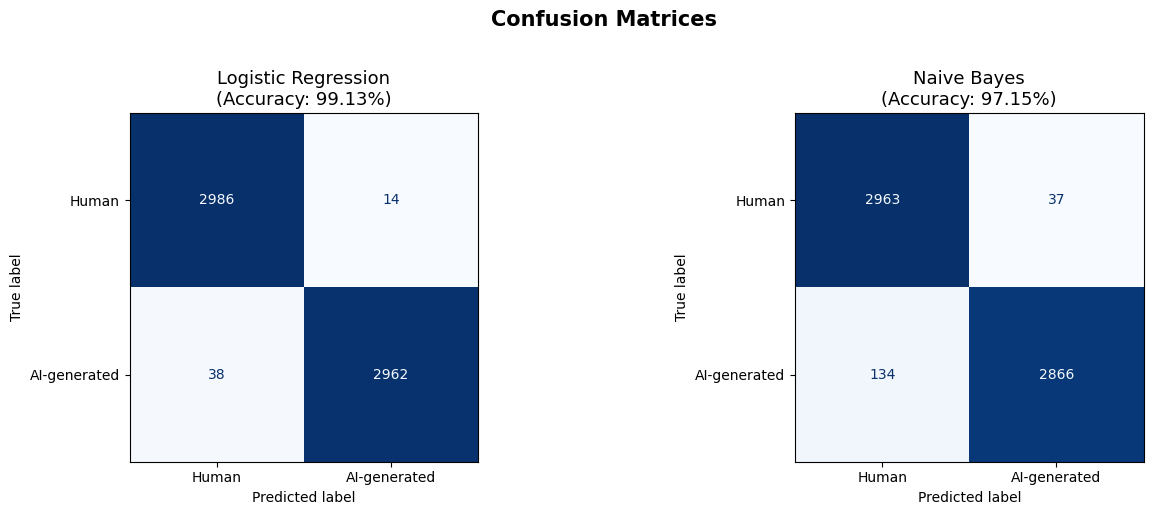


=== Model Comparison Summary ===
              Model Accuracy
Logistic Regression   99.13%
        Naive Bayes   97.15%

Best model selected: Logistic Regression


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in [
    (axes[0], lr_preds, f'Logistic Regression\n(Accuracy: {lr_acc*100:.2f}%)'),
    (axes[1], nb_preds, f'Naive Bayes\n(Accuracy: {nb_acc*100:.2f}%)')
]:
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI-generated'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13)

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Model Comparison Summary ===")
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [f"{lr_acc*100:.2f}%", f"{nb_acc*100:.2f}%"]
})
print(summary.to_string(index=False))

best_model = lr_model if lr_acc >= nb_acc else nb_model
best_name  = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
print(f"\nBest model selected: {best_name}")

---
## Step 8: Intelligent Decision Layer

The model outputs a **probability score** (0 to 1).  
We interpret `P(Human)` — probability that the text is human-written.

| P(Human) | Decision |
|---|---|
| ≥ 0.80 | ✅ Acceptable — High certainty it's human |
| 0.60 – 0.79 | ❓ Needs Review — Borderline, uncertain |
| < 0.60 | ⚠ Likely AI-generated |

**Why these thresholds?**
- 0.80+ means the model is very confident it's human → safe to mark acceptable
- 0.60–0.79 is a gray zone — could go either way → flag for human review
- Below 0.60 means the model leans toward AI → warn the reviewer

In [10]:
def decision_layer(confidence_human):
    """
    Rule-based decision layer based on P(Human) confidence score.
    
    Args:
        confidence_human (float): probability that text is human-written (0 to 1)
    
    Returns:
        str: decision label
    """
    if confidence_human >= 0.80:
        return "Acceptable (High Certainty — Human)"
    elif confidence_human >= 0.60:
        return "Needs Review (Moderate Certainty — Uncertain)"
    else:
        return "Likely AI-generated (Low Certainty)"


def predict_text(text, model=None, show_output=True):
    """
    Full prediction pipeline for a single input text.
    
    Args:
        text  (str)  : raw input text
        model        : trained sklearn model (defaults to best_model)
        show_output  : whether to print results
    
    Returns:
        dict: prediction results
    """
    if model is None:
        model = best_model
    
    # Preprocess
    clean = preprocess_text(text)
    
    # Vectorize
    vec = vectorizer.transform([clean])
    
    # Predict
    label     = model.predict(vec)[0]
    proba     = model.predict_proba(vec)[0]   # [P(AI), P(Human)]
    
    # P(Human) is index 0 since label 0 = Human
    p_human = proba[0]
    p_ai    = proba[1]
    
    prediction = "Human" if label == 0 else "AI-generated"
    confidence = p_human if label == 0 else p_ai
    decision   = decision_layer(p_human)
    
    if show_output:
        print("=" * 55)
        print("         AI vs HUMAN TEXT DETECTION RESULT")
        print("=" * 55)
        print(f"Input text (first 120 chars):")
        print(f"  '{text[:120]}...'" if len(text) > 120 else f"  '{text}'")
        print("-" * 55)
        print(f"  Prediction     : {prediction}")
        print(f"  P(Human)       : {p_human:.4f}  ({p_human*100:.1f}%)")
        print(f"  P(AI)          : {p_ai:.4f}  ({p_ai*100:.1f}%)")
        print(f"  Final Decision : {decision}")
        print("=" * 55)
    
    return {
        'prediction'  : prediction,
        'p_human'     : round(p_human, 4),
        'p_ai'        : round(p_ai, 4),
        'decision'    : decision
    }

print("Prediction function ready!")

Prediction function ready!


---
## Step 9: Live Prediction Demo

### Demo 1 — Sample from Test Split

In [11]:
# Load the held-out test parquet
df_test_official = pd.read_parquet('dataset/test-00000-of-00001.parquet')
print(f"Official test set size: {df_test_official.shape}")
print(df_test_official['generated'].value_counts().rename({0:'Human', 1:'AI'}).to_frame('count'))

Official test set size: (24362, 2)
           count
generated       
Human      15125
AI          9237


In [12]:
# Demo with a human-written sample
human_sample = df_test_official[df_test_official['generated'] == 0].iloc[5]['text']
print("[ ACTUAL LABEL: HUMAN ]")
result_human = predict_text(human_sample)

[ ACTUAL LABEL: HUMAN ]
         AI vs HUMAN TEXT DETECTION RESULT
Input text (first 120 chars):
  'the requirement of some schools to have summer projects in of def to continue the learning process during that break as ...'
-------------------------------------------------------
  Prediction     : Human
  P(Human)       : 0.8843  (88.4%)
  P(AI)          : 0.1157  (11.6%)
  Final Decision : Acceptable (High Certainty — Human)


In [13]:
# Demo with an AI-generated sample
ai_sample = df_test_official[df_test_official['generated'] == 1].iloc[3]['text']
print("[ ACTUAL LABEL: AI-GENERATED ]")
result_ai = predict_text(ai_sample)

[ ACTUAL LABEL: AI-GENERATED ]
         AI vs HUMAN TEXT DETECTION RESULT
Input text (first 120 chars):
  'making your own life decisions can be both highly rewarding and filled with challenges it offers a sense of individualis...'
-------------------------------------------------------
  Prediction     : AI-generated
  P(Human)       : 0.0104  (1.0%)
  P(AI)          : 0.9896  (99.0%)
  Final Decision : Likely AI-generated (Low Certainty)


### Demo 2 — Type Your Own Text

In [ ]:
# ---- Clearly human-like informal text ----
my_text_1 = """
omg i was so tired yesterday i literally fell asleep in the middle of watching netflix lol.
my mom was so mad at me cuz i forgot to do the dishes again. idk why i keep forgetting, 
maybe cause my head is always somewhere else these days. gonna try harder tmrw i guess.
"""

print("--- Custom Input 1 (Informal/Human style) ---")
predict_text(my_text_1)

--- Custom Input 1 (Informal/Human style) ---
         AI vs HUMAN TEXT DETECTION RESULT
Input text (first 120 chars):
  '
omg i was so tired yesterday i literally fell asleep in the middle of watching netflix lol.
my mom was so mad at me cuz...'
-------------------------------------------------------
  Prediction     : AI-generated
  P(Human)       : 0.3755  (37.6%)
  P(AI)          : 0.6245  (62.4%)
  Final Decision : Likely AI-generated (Low Certainty)


{'prediction': 'AI-generated',
 'p_human': np.float64(0.3755),
 'p_ai': np.float64(0.6245),
 'decision': 'Likely AI-generated (Low Certainty)'}

In [ ]:
# ---- Clearly AI-like formal text ----
my_text_2 = """
Climate change presents one of the most significant challenges of the twenty-first century. 
The scientific consensus is unequivocal: global temperatures are rising due to anthropogenic 
greenhouse gas emissions. Addressing this issue requires a multifaceted approach involving 
policy reform, technological innovation, and international cooperation. Governments must 
implement carbon pricing mechanisms and invest in renewable energy infrastructure to ensure 
a sustainable future for subsequent generations.
"""

print("--- Custom Input 2 (Formal/AI style) ---")
predict_text(my_text_2)

--- Custom Input 2 (Formal/AI style) ---
         AI vs HUMAN TEXT DETECTION RESULT
Input text (first 120 chars):
  '
Climate change presents one of the most significant challenges of the twenty-first century. 
The scientific consensus i...'
-------------------------------------------------------
  Prediction     : AI-generated
  P(Human)       : 0.0159  (1.6%)
  P(AI)          : 0.9841  (98.4%)
  Final Decision : Likely AI-generated (Low Certainty)


{'prediction': 'AI-generated',
 'p_human': np.float64(0.0159),
 'p_ai': np.float64(0.9841),
 'decision': 'Likely AI-generated (Low Certainty)'}

---
## Step 10: Batch Evaluation & Confidence Distribution

In [16]:
# Evaluate on 500 samples from the official test set
sample_eval = df_test_official.sample(500, random_state=42).copy()
sample_eval['clean_text'] = sample_eval['text'].apply(preprocess_text)

X_eval_vec = vectorizer.transform(sample_eval['clean_text'])
proba_eval  = best_model.predict_proba(X_eval_vec)

sample_eval['p_human'] = proba_eval[:, 0]
sample_eval['p_ai']    = proba_eval[:, 1]
sample_eval['pred']    = best_model.predict(X_eval_vec)

# Decision layer
sample_eval['decision'] = sample_eval['p_human'].apply(decision_layer)

eval_acc = accuracy_score(sample_eval['generated'], sample_eval['pred'])
print(f"Batch evaluation accuracy (500 samples): {eval_acc*100:.2f}%")

print("\nDecision Distribution:")
print(sample_eval['decision'].value_counts().to_frame('count'))

Batch evaluation accuracy (500 samples): 99.00%

Decision Distribution:
                                               count
decision                                            
Acceptable (High Certainty — Human)              291
Likely AI-generated (Low Certainty)              187
Needs Review (Moderate Certainty — Uncertain)     22


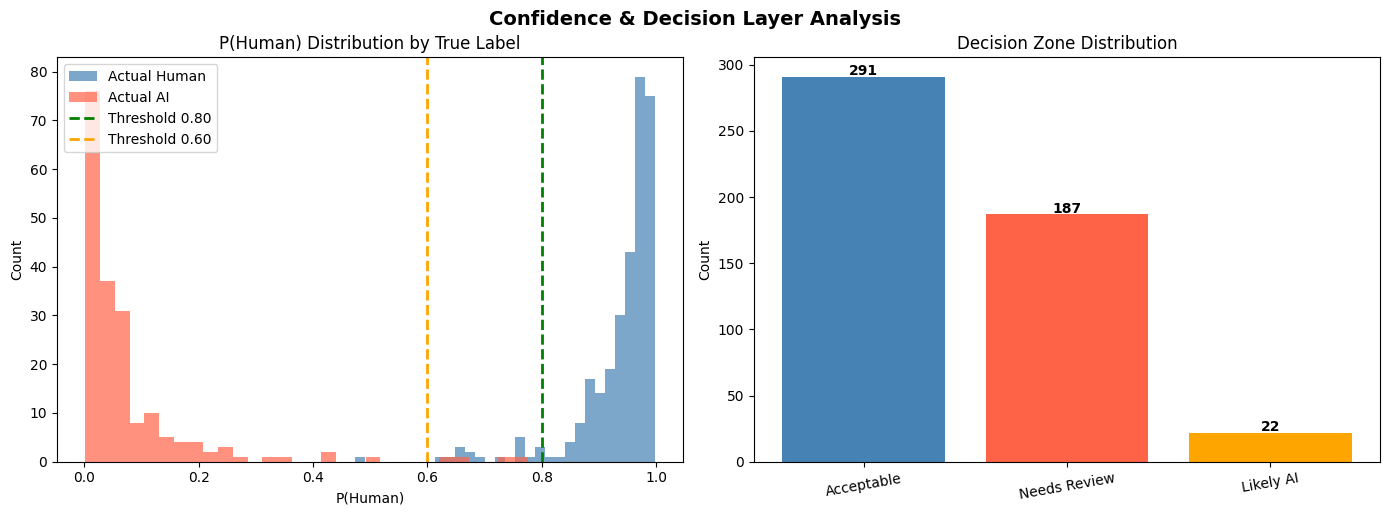

In [17]:
# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: P(Human) for actual Human vs AI texts
human_conf = sample_eval[sample_eval['generated'] == 0]['p_human']
ai_conf    = sample_eval[sample_eval['generated'] == 1]['p_human']

axes[0].hist(human_conf, bins=30, alpha=0.7, color='steelblue', label='Actual Human')
axes[0].hist(ai_conf,    bins=30, alpha=0.7, color='tomato',    label='Actual AI')
axes[0].axvline(0.80, color='green',  linestyle='--', linewidth=2, label='Threshold 0.80')
axes[0].axvline(0.60, color='orange', linestyle='--', linewidth=2, label='Threshold 0.60')
axes[0].set_title('P(Human) Distribution by True Label')
axes[0].set_xlabel('P(Human)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Decision zone breakdown
decision_counts = sample_eval['decision'].value_counts()
colors_map = {
    'Acceptable (High Certainty — Human)' : 'steelblue',
    'Needs Review (Moderate Certainty — Uncertain)' : 'orange',
    'Likely AI-generated (Low Certainty)' : 'tomato'
}
bar_colors = [colors_map.get(k, 'gray') for k in decision_counts.index]
short_labels = ['Acceptable', 'Needs Review', 'Likely AI']

axes[1].bar(range(len(decision_counts)), decision_counts.values, color=bar_colors)
axes[1].set_xticks(range(len(decision_counts)))
axes[1].set_xticklabels(short_labels[:len(decision_counts)], rotation=10)
axes[1].set_title('Decision Zone Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(decision_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.suptitle('Confidence & Decision Layer Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

---
## Step 11: Final Summary

In [18]:
print("=" * 60)
print("         FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset         : AI vs Human Text (Parquet format)")
print(f"Samples used    : 30,000 (15k Human + 15k AI-generated)")
print(f"Train/Test split: 80% / 20%")
print(f"Vectorizer      : TF-IDF (unigrams + bigrams, 50k features)")
print()
print(f"Model Results:")
print(f"  Logistic Regression  → {lr_acc*100:.2f}% accuracy")
print(f"  Naive Bayes          → {nb_acc*100:.2f}% accuracy")
print(f"  Best Model           → {best_name}")
print()
print(f"Decision Layer Thresholds:")
print(f"  P(Human) >= 0.80  →  Acceptable")
print(f"  P(Human)  0.60–0.79  →  Needs Review")
print(f"  P(Human)  < 0.60  →  Likely AI-generated")
print("=" * 60)

         FINAL PROJECT SUMMARY
Dataset         : AI vs Human Text (Parquet format)
Samples used    : 30,000 (15k Human + 15k AI-generated)
Train/Test split: 80% / 20%
Vectorizer      : TF-IDF (unigrams + bigrams, 50k features)

Model Results:
  Logistic Regression  → 99.13% accuracy
  Naive Bayes          → 97.15% accuracy
  Best Model           → Logistic Regression

Decision Layer Thresholds:
  P(Human) >= 0.80  →  Acceptable
  P(Human)  0.60–0.79  →  Needs Review
  P(Human)  < 0.60  →  Likely AI-generated
